# Generate SNI A/B/C METIS datasets for DeepONet

This notebook mirrors `sni/data_generation/generate_eval.py` for the fixed Schwarz (A), holes (B), and Bosch (C) geometries, then creates and saves multiple randomized METIS decompositions. It is independent of the Fluent dataset pipeline.

In [15]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import json
import pickle
import subprocess
import sys

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np

MODULE_DIR = Path.cwd()
if not (MODULE_DIR / 'sni_eval_dataset.py').exists():
    MODULE_DIR = MODULE_DIR / 'DeepONet'
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from sni_eval_dataset import (
    EVAL_MESH_FILES,
    align_mesh_to_solution,
    build_sni_eval_dataset,
    load_sni_pickle,
    mesh_edges,
    metis_partition,
    read_eval_mesh,
    save_sni_eval_dataset_h5,
    unpack_sni_sample,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

The defaults reuse the existing 100-sample Laplace evaluation pickles. Set `GENERATE_FRESH_SOLUTIONS=True` to invoke SNI's FEM generator from this notebook.

In [16]:
SNI_ROOT = Path('/home/hantianl/Documents/sni')
SNI_FEM_PYTHON = Path('/home/hantianl/.miniconda3/envs/sni_fem/bin/python')
GPMETIS = Path('/home/hantianl/.miniconda3/envs/sni_fem/bin/gpmetis')
OUTPUT_DIR = MODULE_DIR / 'data' / 'sni_eval_metis'

PDE_NAME = 'laplace2d'
DOMAINS = ['A', 'B', 'C']
NUM_SAMPLES = 100
N_SUBDOMAINS = 5
N_PARTITION_REALIZATIONS = 5
METIS_UFACTOR = 30  # METIS units: 30 means approximately 3% imbalance
EDGE_WEIGHT_JITTER = 0.10  # varied cuts without overwhelming the mesh geometry
CONTIGUOUS_PARTITIONS = True
VALID_FRACTION = 0.10
TEST_FRACTION = 0.10
SPLIT_SEED = 0
PARTITION_SEED = 0
GENERATE_FRESH_SOLUTIONS = False

SOURCE_PATHS = {
    'A': SNI_ROOT / 'data/2d/laplace2d_schwarz_100_test.pkl',
    'B': SNI_ROOT / 'data/2d/laplace2d_holes_100_test.pkl',
    'C': SNI_ROOT / 'data/2d/laplace2d_bosch_100_test.pkl',
}

print('Output:', OUTPUT_DIR)
print('Sources:', SOURCE_PATHS)

Output: /home/hantianl/Documents/PIDIF/DeepONet/data/sni_eval_metis
Sources: {'A': PosixPath('/home/hantianl/Documents/sni/data/2d/laplace2d_schwarz_100_test.pkl'), 'B': PosixPath('/home/hantianl/Documents/sni/data/2d/laplace2d_holes_100_test.pkl'), 'C': PosixPath('/home/hantianl/Documents/sni/data/2d/laplace2d_bosch_100_test.pkl')}


## Optionally generate fresh SNI solutions

SNI's dolfinx generator uses the `sni_fem` environment, whereas partitioning and DeepONet use `sni_pde`. This cell bridges the two environments while keeping the workflow inside the notebook. Skip it when reusing existing pickles.

In [17]:
if GENERATE_FRESH_SOLUTIONS:
    source_dir = OUTPUT_DIR / 'source'
    source_dir.mkdir(parents=True, exist_ok=True)
    for domain in DOMAINS:
        command = [
            str(SNI_FEM_PYTHON),
            str(SNI_ROOT / 'data_generation/generate_eval.py'),
            '--pde', PDE_NAME,
            '--domain', domain,
            '--num_samples', str(NUM_SAMPLES),
            '--output_dir', str(source_dir),
        ]
        print('Generating', domain)
        subprocess.run(command, cwd=SNI_ROOT, check=True)
        SOURCE_PATHS[domain] = source_dir / f'{PDE_NAME}_{domain}_{NUM_SAMPLES}_test.pkl'
else:
    print('Reusing saved SNI evaluation solutions.')

Reusing saved SNI evaluation solutions.


## Load A/B/C and create randomized METIS partitions

In [18]:
source_by_domain = {}
shape_data = {}
partitions = {}

for domain_index, domain in enumerate(DOMAINS):
    samples = load_sni_pickle(SOURCE_PATHS[domain])
    sol, _, _ = unpack_sni_sample(samples[0])
    mesh_path = SNI_ROOT / 'data/mesh' / EVAL_MESH_FILES[domain]
    mesh_points, triangles = read_eval_mesh(mesh_path)
    points, triangles = align_mesh_to_solution(mesh_points, triangles, sol[:, :2])
    edges = mesh_edges(triangles)

    source_by_domain[domain] = samples
    shape_data[domain] = {
        'points': points,
        'triangles': triangles,
        'edges': edges,
        'mesh_path': str(mesh_path),
    }
    partitions[domain] = []
    for realization_id in range(N_PARTITION_REALIZATIONS):
        seed = PARTITION_SEED + 100_000 * domain_index + realization_id
        labels = metis_partition(
            len(points), edges, N_SUBDOMAINS, seed,
            gpmetis_executable=GPMETIS,
            ufactor=METIS_UFACTOR,
            contiguous=CONTIGUOUS_PARTITIONS,
            edge_weight_jitter=EDGE_WEIGHT_JITTER,
        )
        partitions[domain].append({
            'labels': labels, 'seed': seed, 'n_parts': N_SUBDOMAINS,
        })

    sizes = [np.bincount(part['labels'], minlength=N_SUBDOMAINS).tolist()
             for part in partitions[domain]]
    print(domain, len(points), 'nodes,', len(triangles), 'triangles; sizes:', sizes)


A 729 nodes, 1359 triangles; sizes: [[145, 146, 147, 146, 145], [145, 146, 147, 146, 145], [146, 146, 145, 147, 145], [145, 146, 147, 146, 145], [145, 146, 146, 146, 146]]

B 1038 nodes, 1930 triangles; sizes: [[209, 207, 207, 207, 208], [207, 208, 208, 208, 207], [208, 208, 203, 209, 210], [207, 208, 207, 209, 207], [207, 208, 204, 209, 210]]

C 549 nodes, 897 triangles; sizes: [[109, 109, 111, 112, 108], [110, 109, 110, 110, 110], [112, 110, 109, 110, 108], [109, 110, 110, 111, 109], [110, 110, 110, 110, 109]]


## Split solution samples and save HDF5 datasets

The split occurs by SNI solution sample within every geometry. Each selected solution is expanded over every METIS realization and subdomain.

In [19]:
def split_indices(n_samples, valid_fraction, test_fraction, rng):
    order = rng.permutation(n_samples)
    n_valid = int(round(valid_fraction * n_samples))
    n_test = int(round(test_fraction * n_samples))
    n_train = n_samples - n_valid - n_test
    if n_train < 1:
        raise ValueError('Split leaves no training samples')
    return {
        'train': order[:n_train].astype(int).tolist(),
        'valid': order[n_train:n_train+n_valid].astype(int).tolist(),
        'test': order[n_train+n_valid:].astype(int).tolist(),
    }

split_rng = np.random.default_rng(SPLIT_SEED)
split_by_domain = {
    domain: split_indices(
        len(source_by_domain[domain]), VALID_FRACTION, TEST_FRACTION, split_rng
    )
    for domain in DOMAINS
}
split_by_domain

{'A': {'train': [82,
   36,
   20,
   5,
   93,
   16,
   94,
   52,
   72,
   90,
   83,
   13,
   81,
   37,
   11,
   10,
   75,
   8,
   27,
   9,
   97,
   23,
   22,
   19,
   50,
   98,
   85,
   44,
   71,
   4,
   25,
   70,
   34,
   39,
   64,
   57,
   65,
   42,
   66,
   15,
   30,
   2,
   35,
   86,
   43,
   17,
   74,
   28,
   87,
   18,
   80,
   3,
   1,
   55,
   53,
   24,
   68,
   21,
   47,
   0,
   60,
   6,
   62,
   67,
   45,
   84,
   26,
   51,
   49,
   91,
   92,
   99,
   40,
   61,
   12,
   32,
   96,
   46,
   58,
   14],
  'valid': [73, 38, 88, 31, 89, 48, 77, 76, 7, 63],
  'test': [69, 78, 59, 54, 29, 41, 56, 33, 79, 95]},
 'B': {'train': [94,
   98,
   97,
   68,
   61,
   20,
   80,
   54,
   60,
   58,
   91,
   4,
   21,
   0,
   26,
   74,
   76,
   71,
   73,
   46,
   5,
   33,
   87,
   62,
   38,
   6,
   45,
   39,
   79,
   40,
   86,
   10,
   34,
   13,
   35,
   27,
   89,
   56,
   57,
   99,
   17,
   65,
   24,
   59,
   96,
   2

In [20]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
saved = {}
for split_name in ('train', 'valid', 'test'):
    selected = {domain: split_by_domain[domain][split_name] for domain in DOMAINS}
    data = build_sni_eval_dataset(
        source_by_domain=source_by_domain,
        sample_indices_by_domain=selected,
        shape_data=shape_data,
        partitions=partitions,
        pde_name=PDE_NAME,
    )
    path = OUTPUT_DIR / f'{split_name}.h5'
    save_sni_eval_dataset_h5(data, path)
    saved[split_name] = {'path': str(path), 'n_samples': len(data['samples'])}
    print(split_name, len(data['samples']), 'subdomains ->', path)

manifest = {
    'pde': PDE_NAME,
    'domains': DOMAINS,
    'source_files': {key: str(value) for key, value in SOURCE_PATHS.items()},
    'n_subdomains': N_SUBDOMAINS,
    'n_partition_realizations': N_PARTITION_REALIZATIONS,
    'partition_seed': PARTITION_SEED,
    'metis_ufactor': METIS_UFACTOR,
    'edge_weight_jitter': EDGE_WEIGHT_JITTER,
    'contiguous_partitions': CONTIGUOUS_PARTITIONS,
    'split_seed': SPLIT_SEED,
    'source_sample_indices': split_by_domain,
    'outputs': saved,
}
with (OUTPUT_DIR / 'manifest.json').open('w') as stream:
    json.dump(manifest, stream, indent=2)
print('Saved manifest:', OUTPUT_DIR / 'manifest.json')

train 6000 subdomains -> /home/hantianl/Documents/PIDIF/DeepONet/data/sni_eval_metis/train.h5
valid 750 subdomains -> /home/hantianl/Documents/PIDIF/DeepONet/data/sni_eval_metis/valid.h5
test 750 subdomains -> /home/hantianl/Documents/PIDIF/DeepONet/data/sni_eval_metis/test.h5
Saved manifest: /home/hantianl/Documents/PIDIF/DeepONet/data/sni_eval_metis/manifest.json


## Inspect the saved decompositions

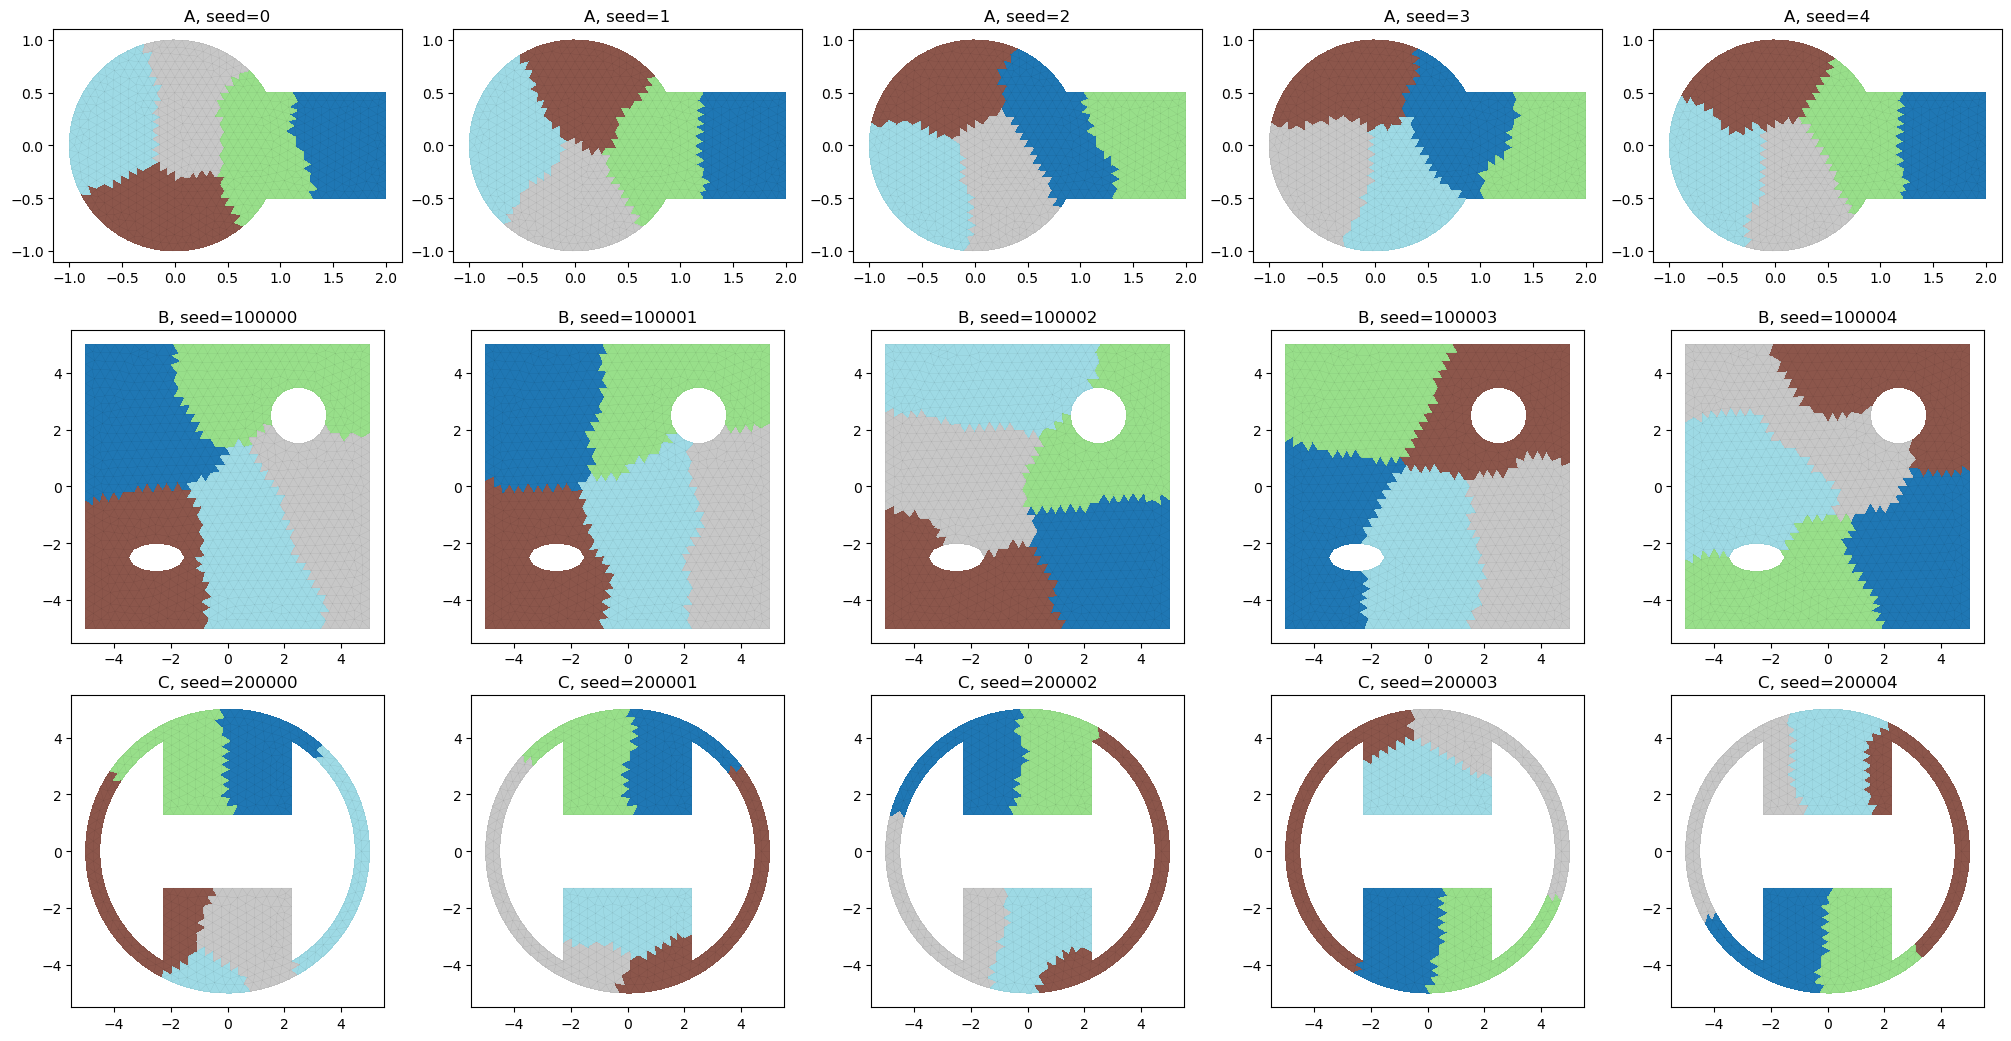

In [21]:
fig, axes = plt.subplots(len(DOMAINS), N_PARTITION_REALIZATIONS,
                         figsize=(4 * N_PARTITION_REALIZATIONS, 3.5 * len(DOMAINS)),
                         squeeze=False, constrained_layout=True)
for row, domain in enumerate(DOMAINS):
    points = shape_data[domain]['points']
    triangles = shape_data[domain]['triangles']
    triangulation = mtri.Triangulation(points[:, 0], points[:, 1], triangles)
    for column, partition in enumerate(partitions[domain]):
        ax = axes[row, column]
        labels = partition['labels']
        triangle_labels = np.asarray([
            np.bincount(labels[triangle], minlength=N_SUBDOMAINS).argmax()
            for triangle in triangles
        ])
        ax.tripcolor(triangulation, facecolors=triangle_labels, shading='flat', cmap='tab20')
        ax.triplot(triangulation, color='black', linewidth=0.1, alpha=0.25)
        ax.set_aspect('equal')
        ax.set_title(f"{domain}, seed={partition['seed']}")
plt.show()